<a href="https://colab.research.google.com/github/Abdou-niang/Congefdsut/blob/main/Copie_de_Pretraiment_des_donnees_textuelle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install wordcloud


## Importation des modules necessaire


In [ ]:
import requests

## III.Récuperation du corpus Textuel


In [ ]:


def wikipedia_page(title):
    """Return the raw text of a Wikipedia page given its title."""
    params = {
        "action": "query",
        "format": "json",
        "titles": title,
        "prop": "extracts",
        "explaintext": True
    }
    headers = {
        "User-Agent": "MyPythonApp/1.0 (contact@example.com)"
    }
    try:
        response = requests.get("https://en.wikipedia.org/w/api.php", params=params, headers=headers)
        response.raise_for_status()  # raise exception for HTTP errors
        data = response.json()
    except requests.exceptions.RequestException as e:
        return f"Request failed: {e}"
    except ValueError:
        return "Failed to parse JSON from Wikipedia API."
    page = next(iter(data["query"]["pages"].values()))
    return page.get("extract", "Page not found")

# Example usage
text = wikipedia_page("Earth").lower()
print(text[:500])  # print first 500 characters to avoid huge output

earth is the third planet from the sun and the only astronomical object known to harbor life. this is made possible by earth being an ocean world, the only one in the solar system sustaining liquid surface water. almost all of earth's water is contained in its global ocean, covering 70.8% of earth's crust. the remaining 29.2% of earth's crust is land, most of which is located in the form of continental landmasses within earth's land hemisphere. most of earth's land is at least somewhat humid and


In [ ]:
text


'earth is the third planet from the sun and the only astronomical object known to harbor life. this is made possible by earth being an ocean world, the only one in the solar system sustaining liquid surface water. almost all of earth\'s water is contained in its global ocean, covering 70.8% of earth\'s crust. the remaining 29.2% of earth\'s crust is land, most of which is located in the form of continental landmasses within earth\'s land hemisphere. most of earth\'s land is at least somewhat humid and covered by vegetation, while large ice sheets at earth\'s polar deserts retain more water than earth\'s groundwater, lakes, rivers, and atmospheric water combined. earth\'s crust consists of slowly moving tectonic plates, which interact to produce mountain ranges, volcanoes, and earthquakes. earth has a liquid outer core that generates a magnetosphere capable of deflecting most of the destructive solar winds and cosmic radiation.\nearth has a dynamic atmosphere, which sustains earth\'s su

## Creation du nuage de mot


In [ ]:
import requests
result =requests.get("https://www.gutenberg.org/files/11/11-0.txt")
print(result.text)

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considering in her

In [ ]:
from wordcloud import WordCloud
wordcloud = WordCloud(random_state=8,
                      normalize_plurals= False,
                      width =600,height=300, max_words=300, stopwords=[])
wordcloud.generate(text)

(np.float64(-0.5), np.float64(599.5), np.float64(299.5), np.float64(-0.5))

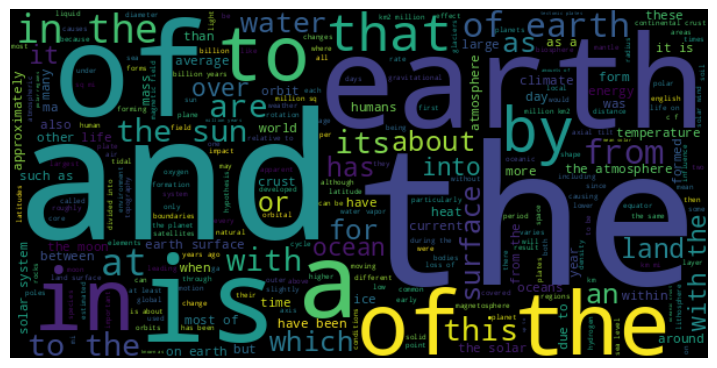

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1,figsize =( 9,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

## Supprimer des mots vides


In [ ]:
from collections import Counter

word_list = text.split(" ")
word_counts = Counter(word_list)

In [ ]:
word_counts

Counter({'earth': 76,
         'is': 175,
         'the': 721,
         'third': 1,
         'planet': 9,
         'from': 71,
         'sun': 27,
         'and': 286,
         'only': 11,
         'astronomical': 4,
         'object': 4,
         'known': 9,
         'to': 168,
         'harbor': 1,
         'life.': 2,
         'this': 44,
         'made': 2,
         'possible': 2,
         'by': 79,
         'being': 7,
         'an': 34,
         'ocean': 20,
         'world,': 3,
         'one': 9,
         'in': 153,
         'solar': 41,
         'system': 10,
         'sustaining': 1,
         'liquid': 8,
         'surface': 43,
         'water.': 3,
         'almost': 3,
         'all': 11,
         'of': 369,
         "earth's": 119,
         'water': 35,
         'contained': 5,
         'its': 42,
         'global': 8,
         'ocean,': 8,
         'covering': 3,
         '70.8%': 2,
         'crust.': 4,
         'remaining': 5,
         '29.2%': 1,
         'crust': 27

In [ ]:
for w in word_counts.most_common(20):
  print(w[0], w[1])

the 721
of 369
and 286
is 175
to 168
in 153
a 132
earth's 119
by 79
earth 76
with 73
from 71
as 69
at 62
that 59
are 51
this 44
it 44
about 44
surface 43
